# Diagnóstico por imagem com CNN (IDC)

Este notebook apresenta uma pipeline completa para classificação binária de imagens histopatológicas de carcinoma ductal invasivo (IDC):

- **Classe 0**: negativo
- **Classe 1**: positivo

## Objetivos
1. Realizar análise exploratória das imagens.
2. Preparar dados com split de treino, validação e teste.
3. Treinar um modelo de rede neural convolucional (CNN).
4. Avaliar desempenho com métricas e matriz de confusão.
5. Interpretar resultados para uso no projeto.

## Resumo técnico do problema

### Variável alvo (target)
O target do modelo é binário e representa a presença de carcinoma ductal invasivo (IDC):
- `0`: negativo
- `1`: positivo

### Objetivo de modelagem
Construir um classificador de imagens histopatológicas que estime a probabilidade de IDC para **apoio à decisão clínica**, priorizando sensibilidade para reduzir risco de falso negativo.

### Critério clínico de interpretação
Como erros de falso negativo podem atrasar condutas importantes, além de `accuracy`, focamos em `recall`, `F1-score`, `AUC` e análise de threshold para ajustar trade-off entre sensibilidade e precisão.

### Formato da saída do modelo
A rede produz um **logit** convertido em **probabilidade** `p` no intervalo [0, 1] via sigmoide. A classe prevista depende do **limiar** (p.ex. 0,5 ou limiar otimizado na validação — ver seção 7).

### Metodologia dos dados (para o relatório acadêmico)
- **Origem:** imagens organizadas em `data/0` (negativo) e `data/1` (positivo), relativas ao projeto.
- **Split:** 70% treino, 15% validação, 15% teste, com **estratificação** para preservar a proporção de classes em cada parte.
- **Papel de cada conjunto:** treino (ajuste dos pesos), validação (early stopping, escolha de limiar), teste (**uma única avaliação final** de generalização, sem ajuste de hiperparâmetros).

### Reprodutibilidade (mínimo acadêmico)
- `SEED` fixo para `random`, `numpy` e `torch.manual_seed`.
- Dependências listadas em `requirements.txt` do repositório; executar o notebook de cima a baixo após `pip install -r requirements.txt`.

## 1) Importações, configurações e paths

In [1]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
CLASS0_DIR = DATA_DIR / "0"
CLASS1_DIR = DATA_DIR / "1"

if not CLASS0_DIR.exists() or not CLASS1_DIR.exists():
    raise FileNotFoundError(f"Pastas de classe não encontradas em: {DATA_DIR}")

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Projeto: {PROJECT_ROOT}")
print(f"Dados: {DATA_DIR}")
print(f"Device: {DEVICE}")

Projeto: c:\Users\Kelvin\Downloads\Tech-Challenge-FIAP-main\Tech-Challenge-FIAP-main
Dados: c:\Users\Kelvin\Downloads\Tech-Challenge-FIAP-main\Tech-Challenge-FIAP-main\data
Device: cpu


## 2) Análise exploratória das imagens

Nesta etapa levantamos:
- quantidade por classe
- distribuição (balanceamento)
- inspeção visual de amostras

Total de imagens: 100
Classe 0 (negativo): 50
Classe 1 (positivo): 50
Proporção classe 1: 50.00%


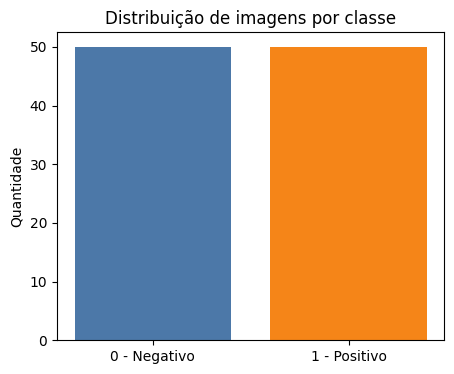

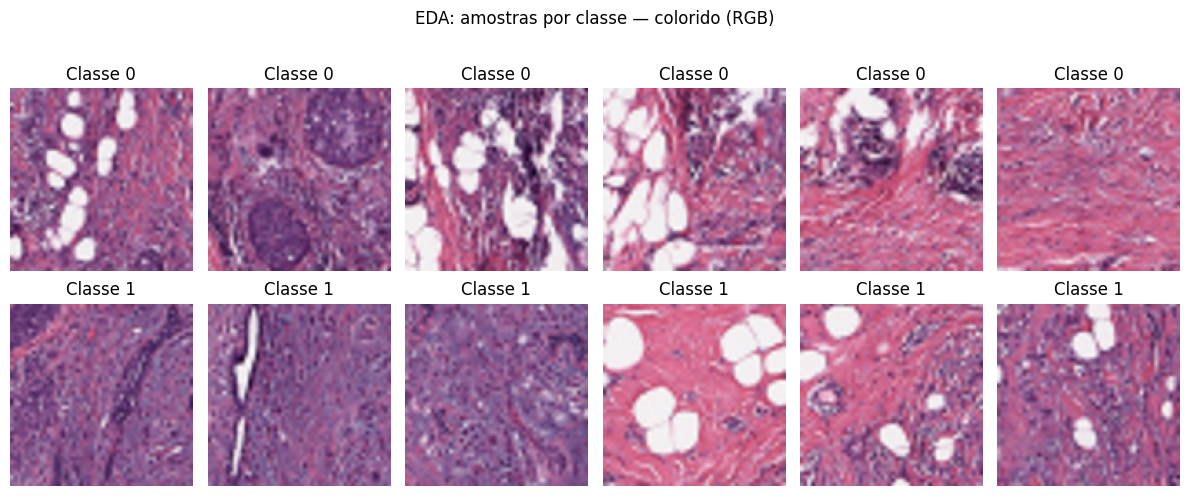

### Por que mostramos **colorido** e depois **preto e branco**? (visão computacional)

- **Imagem colorida (RGB):** em histopatologia digital, **cor e tingimento** carregam informação (densidade do corante, protocolo de coloração, variação entre laboratórios). Olhar em RGB aproxima a EDA do que o patologista observa e ajuda a detectar **artefatos** ou **diferenças de cor** entre classes.

- **Escala de cinza (luminância):** ao converter para um único canal de intensidade, reduzimos a influência da **cor como distração** e destacamos **textura, bordas e contraste local** — pistas estruturais que muitas redes convolucionais exploram. Isso é útil para comparar **padrões morfológicos** entre recortes.

**Neste projeto:** o treino da CNN continua com **3 canais (RGB)** (padrão em pipelines de classificação de imagens); o bloco em tons de cinza é **complementar na EDA**, recurso clássico em visão computacional para validar o que pode ser aprendido além da cor.

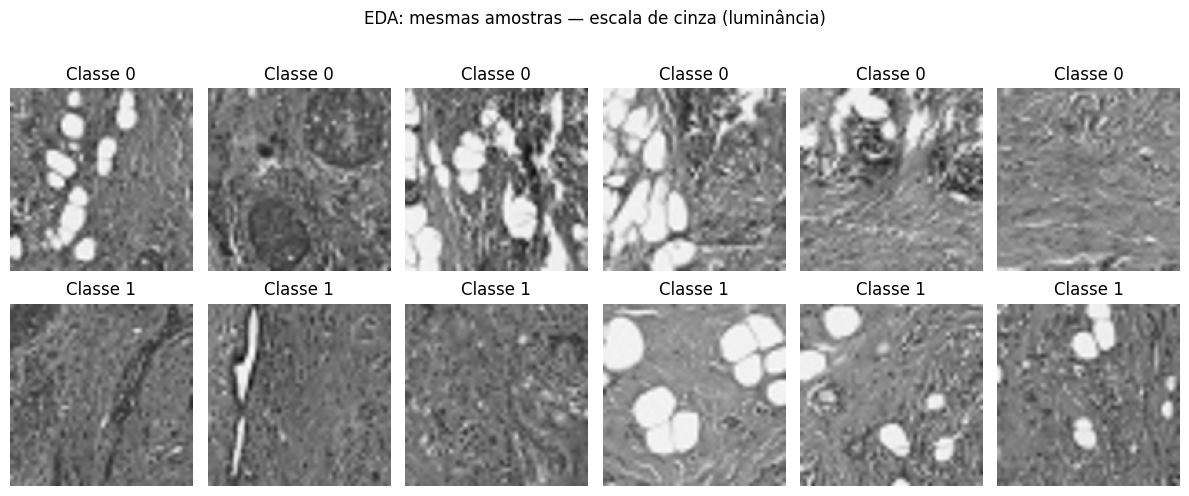

In [2]:
files_0 = sorted([p for p in CLASS0_DIR.iterdir() if p.is_file()])
files_1 = sorted([p for p in CLASS1_DIR.iterdir() if p.is_file()])

count_0 = len(files_0)
count_1 = len(files_1)
total = count_0 + count_1

print(f"Total de imagens: {total}")
print(f"Classe 0 (negativo): {count_0}")
print(f"Classe 1 (positivo): {count_1}")
print(f"Proporção classe 1: {count_1/total:.2%}")

# Gráfico de distribuição por classe
plt.figure(figsize=(5, 4))
plt.bar(["0 - Negativo", "1 - Positivo"], [count_0, count_1], color=["#4C78A8", "#F58518"])
plt.title("Distribuição de imagens por classe")
plt.ylabel("Quantidade")
plt.show()

from IPython.display import display, Markdown

# 1) Inspeção em COR (RGB): tingimento e aparência "como na lâmina"
N_SHOW = 6
sample_0 = files_0[:N_SHOW]
sample_1 = files_1[:N_SHOW]

fig, axes = plt.subplots(2, N_SHOW, figsize=(2 * N_SHOW, 5))
for j, f in enumerate(sample_0):
    img = np.asarray(Image.open(f).convert("RGB").resize(IMG_SIZE), dtype=np.uint8)
    axes[0, j].imshow(img)
    axes[0, j].set_title("Classe 0")
    axes[0, j].axis("off")
for j, f in enumerate(sample_1):
    img = np.asarray(Image.open(f).convert("RGB").resize(IMG_SIZE), dtype=np.uint8)
    axes[1, j].imshow(img)
    axes[1, j].set_title("Classe 1")
    axes[1, j].axis("off")
axes[0, 0].set_ylabel("Negativo (0)", fontsize=11)
axes[1, 0].set_ylabel("Positivo (1)", fontsize=11)
plt.suptitle("EDA: amostras por classe — colorido (RGB)", y=1.02)
plt.tight_layout()
plt.show()

display(
    Markdown(
        "### Por que mostramos **colorido** e depois **preto e branco**? (visão computacional)\n\n"
        "- **Imagem colorida (RGB):** em histopatologia digital, **cor e tingimento** carregam informação (densidade do corante, protocolo de coloração, variação entre laboratórios). Olhar em RGB aproxima a EDA do que o patologista observa e ajuda a detectar **artefatos** ou **diferenças de cor** entre classes.\n\n"
        "- **Escala de cinza (luminância):** ao converter para um único canal de intensidade, reduzimos a influência da **cor como distração** e destacamos **textura, bordas e contraste local** — pistas estruturais que muitas redes convolucionais exploram. Isso é útil para comparar **padrões morfológicos** entre recortes.\n\n"
        "**Neste projeto:** o treino da CNN continua com **3 canais (RGB)** (padrão em pipelines de classificação de imagens); o bloco em tons de cinza é **complementar na EDA**, recurso clássico em visão computacional para validar o que pode ser aprendido além da cor."
    )
)

# 2) Mesmas amostras em PRETO E BRANCO (L): ênfase em textura/contraste
fig, axes = plt.subplots(2, N_SHOW, figsize=(2 * N_SHOW, 5))
for j, f in enumerate(sample_0):
    img = np.asarray(Image.open(f).convert("L").resize(IMG_SIZE), dtype=np.uint8)
    axes[0, j].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, j].set_title("Classe 0")
    axes[0, j].axis("off")
for j, f in enumerate(sample_1):
    img = np.asarray(Image.open(f).convert("L").resize(IMG_SIZE), dtype=np.uint8)
    axes[1, j].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[1, j].set_title("Classe 1")
    axes[1, j].axis("off")
axes[0, 0].set_ylabel("Negativo (0)", fontsize=11)
axes[1, 0].set_ylabel("Positivo (1)", fontsize=11)
plt.suptitle("EDA: mesmas amostras — escala de cinza (luminância)", y=1.02)
plt.tight_layout()
plt.show()

In [3]:
# Analise quantitativa simples das imagens por classe
# (suporte para discutir qualidade de dados e separabilidade inicial)

def summarize_image_set(paths, max_images=300):
    sample = paths[: min(len(paths), max_images)]
    means = []
    stds = []
    sizes = []
    for p in sample:
        arr = np.array(Image.open(p).convert("RGB"), dtype=np.float32) / 255.0
        means.append(arr.mean(axis=(0, 1)))
        stds.append(arr.std(axis=(0, 1)))
        sizes.append(arr.shape[:2])
    means = np.array(means)
    stds = np.array(stds)
    h = np.array([s[0] for s in sizes])
    w = np.array([s[1] for s in sizes])
    return {
        "n_amostra": len(sample),
        "mean_rgb": means.mean(axis=0),
        "std_rgb": stds.mean(axis=0),
        "altura_media": h.mean(),
        "largura_media": w.mean(),
    }

stats_0 = summarize_image_set(files_0)
stats_1 = summarize_image_set(files_1)

print("Resumo classe 0 (negativo):", stats_0)
print("Resumo classe 1 (positivo):", stats_1)

Resumo classe 0 (negativo): {'n_amostra': 50, 'mean_rgb': array([0.75445724, 0.54379153, 0.6653786 ], dtype=float32), 'std_rgb': array([0.1136514 , 0.1686801 , 0.12674817], dtype=float32), 'altura_media': np.float64(50.0), 'largura_media': np.float64(50.0)}
Resumo classe 1 (positivo): {'n_amostra': 50, 'mean_rgb': array([0.60385424, 0.39156318, 0.566295  ], dtype=float32), 'std_rgb': array([0.10088093, 0.11827394, 0.09082627], dtype=float32), 'altura_media': np.float64(50.0), 'largura_media': np.float64(50.0)}


### O que levantamos na análise das imagens

- Verificamos volume por classe e balanceamento inicial (fundamental para evitar viés de treino).
- Exibimos **amostras lado a lado por classe**: primeiro em **RGB (colorido)** e, em seguida, as **mesmas imagens em escala de cinza**, com texto explicando o papel de cada visualização na visão computacional.
- Calculamos estatísticas simples (média/desvio por canal RGB e dimensões), úteis para justificar normalização e redimensionamento.
- Na seção **2.1**, aplicamos **OpenCV + Tesseract**: denoise, **Otsu**, **limiar adaptativa** e OCR (`por`+`eng`) em uma amostra por classe — com nota crítica sobre a presença (ou ausência) de texto em imagens histopatológicas.

Esses pontos sustentam as escolhas de pré-processamento usadas no pipeline e ajudam a interpretar erros do modelo mais adiante.

## 2.1) Pré-processamento para OCR com OpenCV e Tesseract

Depois da análise em **escala de cinza**, aplicamos um fluxo típico de **extração de texto a partir de imagens**:

- **Redução de ruído** (filtro espacial);
- **Limiarização global** com **método de Otsu**;
- **Limiarização adaptativa** (útil quando a iluminação varia no campo);
- **Tesseract OCR** (`por` + `eng`) sobre as imagens binarizadas.

**Observação:** lâminas histopatológicas (patches de tecido) costumam **não conter texto impresso** como um documento escaneado. O foco aqui é **demonstrar o pipeline** de pré-processamento e integração OCR no mesmo projeto; o texto extraído pode ser vazio ou espúrio — isso também faz parte da interpretação crítica.

**Ambiente:** as instruções de instalação do Tesseract na célula seguinte estão voltadas para **Microsoft Windows**.

### Instalação no **Windows** (ambiente do projeto)

1. Baixe e instale o **Tesseract para Windows** (instalador recomendado pela comunidade): [UB Mannheim — Tesseract](https://github.com/UB-Mannheim/tesseract/wiki).
2. Durante a instalação, marque a opção para adicionar o Tesseract ao **PATH** *ou* anote o caminho do `tesseract.exe` (geralmente `C:\\Program Files\\Tesseract-OCR\\tesseract.exe`).
3. Para OCR em **português**, inclua os **traineddata** de `por` (no instalador, selecione idiomas adicionais, ou copie `por.traineddata` para a pasta `tessdata` da instalação).
4. (Opcional) Se o comando `tesseract` não for encontrado, defina a variável de ambiente do usuário **`TESSERACT_CMD`** com o caminho completo do `tesseract.exe`, ou o código da próxima célula tenta localizar automaticamente em pastas padrão.

**Pacotes Python:** a célula seguinte usa **`%pip install`** para instalar no **mesmo ambiente do kernel do Jupyter** (recomendado). Se preferir o terminal, na pasta do projeto:

```bash
pip install opencv-python-headless pytesseract
```

Se aparecer `No module named 'cv2'`, quase sempre o notebook está usando outro Python — **rode a célula `%pip`** e depois a célula de importação de novo.

*Referência (Linux):* em Ubuntu/Debian usariam `apt install tesseract-ocr tesseract-ocr-por libtesseract-dev`; **este trabalho assume Windows**.

In [10]:
# Instala neste kernel do Jupyter (o Python do terminal pode ser outro — isso corrige o erro `No module named 'cv2'`)
%pip install -q opencv-python-headless pytesseract

Note: you may need to restart the kernel to use updated packages.


In [9]:
import os
import shutil

try:
    import cv2
    import pytesseract
except ImportError as e:
    raise ImportError(
        "Execute a célula acima com %pip install (ou: pip install opencv-python-headless pytesseract no mesmo Python do kernel)."
    ) from e

# Tesseract no Windows: variável de ambiente TESSERACT_CMD, PATH, ou pastas padrão
TESSERACT_CMD = os.environ.get("TESSERACT_CMD", "").strip()
tesseract_ok = False
if TESSERACT_CMD:
    pytesseract.pytesseract.tesseract_cmd = TESSERACT_CMD
    tesseract_ok = True
elif shutil.which("tesseract") is not None:
    tesseract_ok = True
elif os.name == "nt":
    for candidate in (
        r"C:\Program Files\Tesseract-OCR\tesseract.exe",
        r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe",
    ):
        if os.path.isfile(candidate):
            pytesseract.pytesseract.tesseract_cmd = candidate
            tesseract_ok = True
            print(f"Tesseract (Windows): usando {candidate}")
            break

if not tesseract_ok:
    print(
        "Aviso: Tesseract não encontrado. Instale no Windows (veja markdown acima), "
        "adicione ao PATH ou defina TESSERACT_CMD com o caminho do tesseract.exe."
    )

# Idiomas: português + inglês (no Windows: traineddata por/eng na pasta tessdata)
OCR_LANG = "por+eng"


def ocr_preprocess_pipeline(bgr: np.ndarray) -> dict:
    """Ruído + Otsu + limiarização adaptativa."""
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    # Redução de ruído preservando bordas (bom para manchas/pequenos artefatos)
    den = cv2.fastNlMeansDenoising(gray, None, h=10, templateWindowSize=7, searchWindowSize=21)
    # Otsu: limiar global automático
    _, otsu = cv2.threshold(den, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Adaptativo: bloco local (iluminação não uniforme)
    adapt = cv2.adaptiveThreshold(
        den, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )
    return {"gray": gray, "denoise": den, "otsu": otsu, "adaptive": adapt}


def run_ocr_on_binary(img_bin: np.ndarray) -> str:
    try:
        return pytesseract.image_to_string(img_bin, lang=OCR_LANG).strip()
    except pytesseract.TesseractNotFoundError:
        return "[Tesseract não instalado ou não encontrado no PATH]"
    except Exception as e:
        return f"[Erro OCR: {e}]"


# Uma amostra por classe (negativo / positivo)
samples_ocr = []
if len(files_0) > 0:
    samples_ocr.append((0, files_0[0]))
if len(files_1) > 0:
    samples_ocr.append((1, files_1[0]))

for label, path in samples_ocr:
    bgr = cv2.imread(str(path))
    if bgr is None:
        print(f"Não foi possível ler: {path}")
        continue

    bgr = cv2.resize(bgr, IMG_SIZE, interpolation=cv2.INTER_AREA)
    out = ocr_preprocess_pipeline(bgr)

    txt_otsu = run_ocr_on_binary(out["otsu"])
    txt_adapt = run_ocr_on_binary(out["adaptive"])

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    axes[0, 0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title(f"Original (classe {label})")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(out["gray"], cmap="gray")
    axes[0, 1].set_title("Cinza")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(out["denoise"], cmap="gray")
    axes[0, 2].set_title("Denoise (NL-means)")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(out["otsu"], cmap="gray")
    axes[1, 0].set_title("Otsu (binário)")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(out["adaptive"], cmap="gray")
    axes[1, 1].set_title("Limiar adaptativo")
    axes[1, 1].axis("off")

    axes[1, 2].axis("off")
    axes[1, 2].text(
        0.02,
        0.95,
        f"OCR (Otsu), lang={OCR_LANG}:\n{txt_otsu or '(vazio)'}\n\n"
        f"OCR (adaptativo):\n{txt_adapt or '(vazio)'}",
        transform=axes[1, 2].transAxes,
        fontsize=9,
        verticalalignment="top",
        fontfamily="monospace",
    )

    plt.suptitle(f"Pipeline OCR — classe {label} — {path.name}", y=1.02)
    plt.tight_layout()
    plt.show()

ImportError: Execute a célula acima com %pip install (ou: pip install opencv-python-headless pytesseract no mesmo Python do kernel).

## 3) Preparação dos dados (train/val/test)

Split estratificado em três conjuntos:
- **Treino**: 70%
- **Validação**: 15%
- **Teste**: 15%

### Estratégia de pré-processamento (essencial para o modelo)

- **Split estratificado** em treino/validação/teste para manter proporção de classes e evitar viés de avaliação quando há desbalanceamento leve ou moderado.
- **Resize padronizado** para `128x128` para batches homogêneos, uso estável de memória e arquitetura com convoluções/pooling previsíveis.
- **Conversão para tensor e normalização [0, 1]** para estabilizar gradientes e manter escala compatível com `BCEWithLogitsLoss` e inicialização usual dos pesos.
- **Data augmentation só no treino** (espelhamento, rotação leve) para simular variações de orientação/recorte sem alterar o rótulo, **sem tocar** validação/teste — reduz overfitting sem contaminar a estimativa de desempenho.
- **Teste reservado ao final:** validação decide parada antecipada e limiar; o teste mede generalização **após** o experimento estar definido.

In [10]:
all_files = files_0 + files_1
all_labels = np.array([0] * len(files_0) + [1] * len(files_1), dtype=np.int64)
all_files = np.array([str(p) for p in all_files])

X_train, X_temp, y_train, y_temp = train_test_split(
    all_files,
    all_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=all_labels,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

print(f"Treino: {len(X_train)}")
print(f"Validação: {len(X_val)}")
print(f"Teste: {len(X_test)}")

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

class IDCDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

train_ds = IDCDataset(X_train, y_train, transform=train_transform)
val_ds = IDCDataset(X_val, y_val, transform=eval_transform)
test_ds = IDCDataset(X_test, y_test, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Treino: 70
Validação: 15
Teste: 15


### Escolha do modelo e justificativa

Optamos por uma **CNN** porque o problema depende de padrões espaciais locais (bordas, texturas e estruturas celulares) que redes convolucionais capturam melhor do que modelos tabulares clássicos.

Arquitetura escolhida:
- 3 blocos convolucionais com pooling para extração hierárquica de features;
- camadas densas finais para decisão binária;
- `Dropout` para reduzir overfitting.

Também utilizamos:
- data augmentation no treino (melhora generalização);
- early stopping via validação (evita overfitting tardio).

## 4) Definição e treinamento do modelo CNN

### O que observar durante o treinamento

- Se `train_loss` cai e `val_loss` também cai de forma consistente, há bom aprendizado.
- Se `train_loss` continua caindo e `val_loss` sobe, há sinal de overfitting.
- AUC de validação indica qualidade de ranqueamento das probabilidades e complementa a acurácia.

Neste projeto, as curvas servem para justificar a escolha do ponto de parada e apoiar a confiabilidade da avaliação final em teste.

Epoch 01/20 | train_loss=0.6948 train_acc=0.5286 | val_loss=0.6833 val_acc=0.5333 val_auc=0.9464
Epoch 02/20 | train_loss=0.6825 train_acc=0.5714 | val_loss=0.5999 val_acc=0.6667 val_auc=0.8750
Epoch 03/20 | train_loss=0.6029 train_acc=0.7714 | val_loss=0.5104 val_acc=0.9333 val_auc=0.8750
Epoch 04/20 | train_loss=0.5059 train_acc=0.7857 | val_loss=0.6068 val_acc=0.6667 val_auc=0.8750
Epoch 05/20 | train_loss=0.4663 train_acc=0.7714 | val_loss=0.6988 val_acc=0.5333 val_auc=0.8750
Epoch 06/20 | train_loss=0.6466 train_acc=0.7000 | val_loss=0.4596 val_acc=0.7333 val_auc=0.8750
Epoch 07/20 | train_loss=0.5036 train_acc=0.7714 | val_loss=0.5052 val_acc=0.6000 val_auc=0.8750
Epoch 08/20 | train_loss=0.4763 train_acc=0.8000 | val_loss=0.4834 val_acc=0.7333 val_auc=0.8750
Epoch 09/20 | train_loss=0.4753 train_acc=0.7714 | val_loss=0.3350 val_acc=0.9333 val_auc=0.8750
Epoch 10/20 | train_loss=0.4835 train_acc=0.8429 | val_loss=0.3146 val_acc=0.9333 val_auc=0.8750
Epoch 11/20 | train_loss=0.463

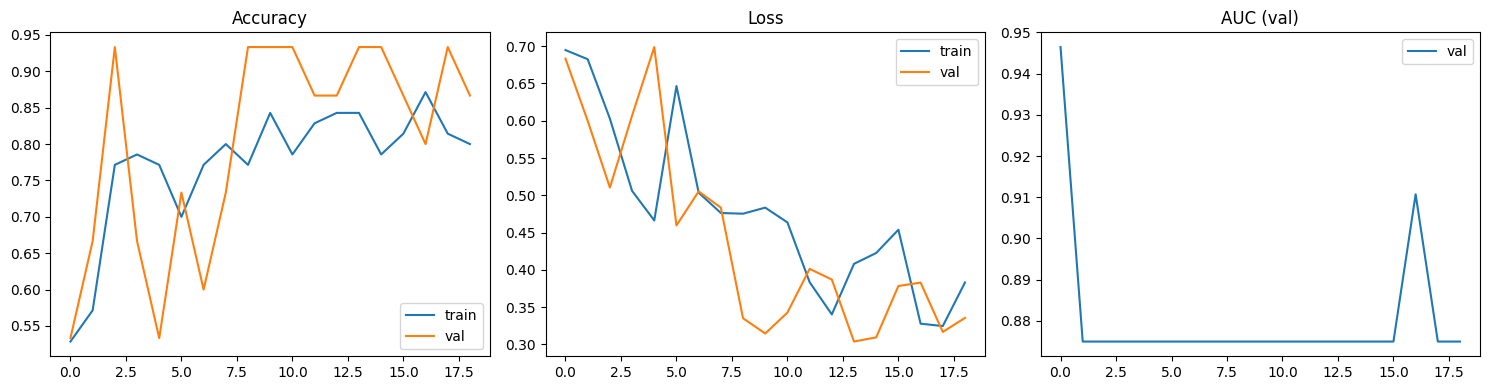

In [11]:
class IDC_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x).squeeze(1)

model = IDC_CNN().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_auc": []}
best_val_loss = float("inf")
patience = 5
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    # Treino
    model.train()
    train_losses = []
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        preds = (torch.sigmoid(logits) >= 0.5).float()
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss = float(np.mean(train_losses))
    train_acc = train_correct / train_total

    # Validação
    model.eval()
    val_losses = []
    val_correct = 0
    val_total = 0
    val_true = []
    val_prob = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_losses.append(loss.item())

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
            val_true.extend(y_batch.cpu().numpy().astype(int))
            val_prob.extend(probs.cpu().numpy())

    val_loss = float(np.mean(val_losses))
    val_acc = val_correct / val_total
    val_auc = roc_auc_score(val_true, val_prob)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_auc={val_auc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping acionado.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# Curvas de treino
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_acc"], label="train")
axes[0].plot(history["val_acc"], label="val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history["train_loss"], label="train")
axes[1].plot(history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].legend()

axes[2].plot(history["val_auc"], label="val")
axes[2].set_title("AUC (val)")
axes[2].legend()

plt.tight_layout()
plt.show()

## 5) Avaliação no conjunto de teste

Nesta etapa usamos apenas o **conjunto de teste** (não visto no treino) para medir generalização.

### Discussão de métricas (ângulo acadêmico)

| Métrica | O que mede | Por que importa neste trabalho |
|--------|------------|--------------------------------|
| **Acurácia** | fração de acertos globais | Fácil de comunicar, mas pode mascarar desbalanceamento. |
| **AUC-ROC** | capacidade de **ordenar** positivos acima de negativos | Útil quando a probabilidade será usada como **score de risco**, independentemente de um limiar fixo. |
| **Recall / Precision / F1** | sensibilidade, precisão e equilíbrio por limiar | Em triagem, **recall** alto reduz risco de **falso negativo**; **precision** controla alarmes falsos. O **F1** resume o trade-off. |
| **Matriz de confusão** | erros por tipo (VP, VN, FP, FN) | Base para narrar impacto dos erros na prática. |

**Limiar:** o valor 0,5 é convencional; a seção 7 ajusta o limiar na **validação** e compara no **teste**, o que é método correto para relatório (evita otimizar no teste).

Teste - Loss: 0.4647
Teste - Accuracy: 0.8667
Teste - AUC: 0.8750

Classification report (teste):
              precision    recall  f1-score   support

negativo (0)       0.88      0.88      0.88         8
positivo (1)       0.86      0.86      0.86         7

    accuracy                           0.87        15
   macro avg       0.87      0.87      0.87        15
weighted avg       0.87      0.87      0.87        15



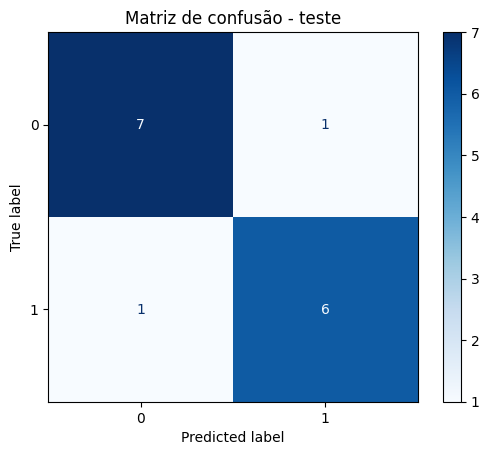

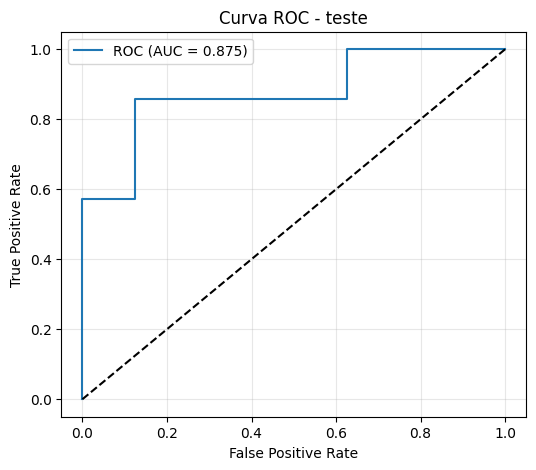

In [12]:
model.eval()
test_losses = []
y_true = []
y_prob = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        probs = torch.sigmoid(logits)

        test_losses.append(loss.item())
        y_true.extend(y_batch.cpu().numpy().astype(int))
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

test_loss = float(np.mean(test_losses))
test_acc = float((y_pred == y_true).mean())
test_auc = roc_auc_score(y_true, y_prob)

print(f"Teste - Loss: {test_loss:.4f}")
print(f"Teste - Accuracy: {test_acc:.4f}")
print(f"Teste - AUC: {test_auc:.4f}")

print("\nClassification report (teste):")
print(classification_report(y_true, y_pred, target_names=["negativo (0)", "positivo (1)"]))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"]).plot(cmap="Blues")
plt.title("Matriz de confusão - teste")
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - teste")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6) Predições visuais e salvamento do modelo

In [1]:
sample_images, sample_labels = next(iter(test_loader))
model.eval()
with torch.no_grad():
    logits = model(sample_images[:9].to(DEVICE))
    sample_probs = torch.sigmoid(logits).cpu().numpy().ravel()

sample_preds = (sample_probs >= 0.5).astype(int)

plt.figure(figsize=(10, 10))
for i in range(min(9, len(sample_images))):
    ax = plt.subplot(3, 3, i + 1)
    img_np = sample_images[i].permute(1, 2, 0).numpy()
    plt.imshow((img_np * 255).astype("uint8"))
    plt.title(f"Real: {int(sample_labels[i])} | Pred: {sample_preds[i]} ({sample_probs[i]:.2f})")
    plt.axis("off")
plt.tight_layout()
plt.show()

MODEL_PATH = PROJECT_ROOT / "cnn_idc_model.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Modelo salvo em: {MODEL_PATH}")

NameError: name 'test_loader' is not defined

## 7) Melhorias de avaliação e análise de erro

Para deixar a entrega mais robusta, vamos complementar a avaliação com:

1. ajuste de limiar (threshold) com base na validação;
2. curva Precision-Recall e F1 por threshold;
3. comparação de métricas no threshold padrão (0.50) vs threshold otimizado;
4. inspeção visual dos erros (falsos positivos e falsos negativos).

Melhor threshold (val) por F1: 0.543
F1 na validação: 0.9412


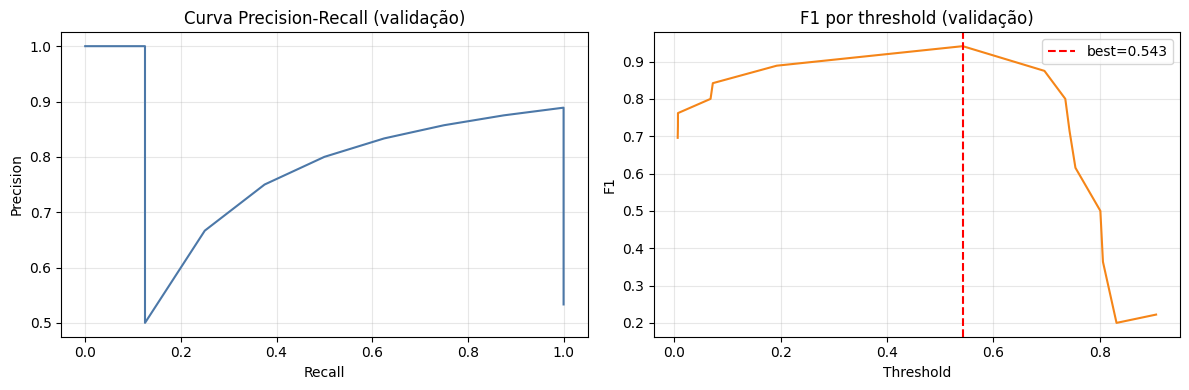

In [17]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score

# Probabilidades na validacao para escolher threshold
model.eval()
val_true = []
val_prob = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        val_prob.extend(probs)
        val_true.extend(y_batch.numpy())

val_true = np.array(val_true).astype(int)
val_prob = np.array(val_prob)

prec, rec, thr = precision_recall_curve(val_true, val_prob)
# precision_recall_curve retorna arrays com tamanho diferente para threshold
f1_vals = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-9)
best_idx = int(np.argmax(f1_vals))
best_thr = float(thr[best_idx])

print(f"Melhor threshold (val) por F1: {best_thr:.3f}")
print(f"F1 na validação: {f1_vals[best_idx]:.4f}")

# Curvas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rec, prec, color="#4C78A8")
axes[0].set_title("Curva Precision-Recall (validação)")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].grid(alpha=0.3)

axes[1].plot(thr, f1_vals, color="#F58518")
axes[1].axvline(best_thr, color="red", linestyle="--", label=f"best={best_thr:.3f}")
axes[1].set_title("F1 por threshold (validação)")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

=== Threshold 0.50 (padrão) ===
Precision: 0.8571
Recall:    0.8571
F1-score:  0.8571

=== Threshold otimizado (validação) ===
Threshold: 0.543
Precision: 0.8571
Recall:    0.8571
F1-score:  0.8571


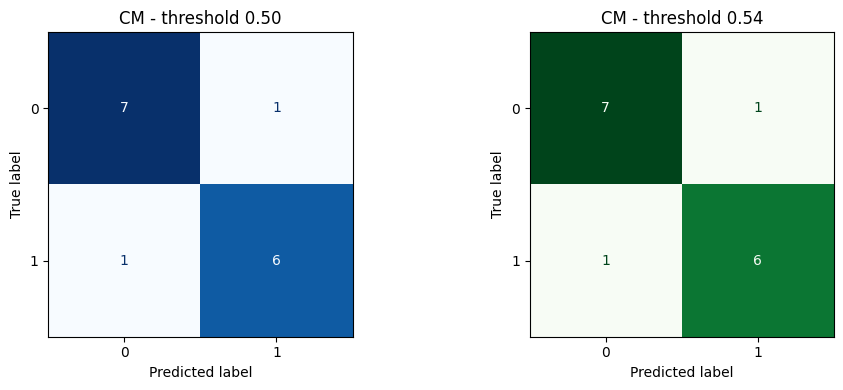

In [15]:
# Compara teste com threshold padrao vs threshold otimizado
pred_default = (y_prob >= 0.5).astype(int)
pred_opt = (y_prob >= best_thr).astype(int)

print("=== Threshold 0.50 (padrão) ===")
print(f"Precision: {precision_score(y_true, pred_default):.4f}")
print(f"Recall:    {recall_score(y_true, pred_default):.4f}")
print(f"F1-score:  {f1_score(y_true, pred_default):.4f}")

print("\n=== Threshold otimizado (validação) ===")
print(f"Threshold: {best_thr:.3f}")
print(f"Precision: {precision_score(y_true, pred_opt):.4f}")
print(f"Recall:    {recall_score(y_true, pred_opt):.4f}")
print(f"F1-score:  {f1_score(y_true, pred_opt):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_default = confusion_matrix(y_true, pred_default)
cm_opt = confusion_matrix(y_true, pred_opt)

ConfusionMatrixDisplay(cm_default, display_labels=["0", "1"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("CM - threshold 0.50")

ConfusionMatrixDisplay(cm_opt, display_labels=["0", "1"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"CM - threshold {best_thr:.2f}")

plt.tight_layout()
plt.show()

Total erros (threshold=0.543): 2
Falsos positivos: 1
Falsos negativos: 1


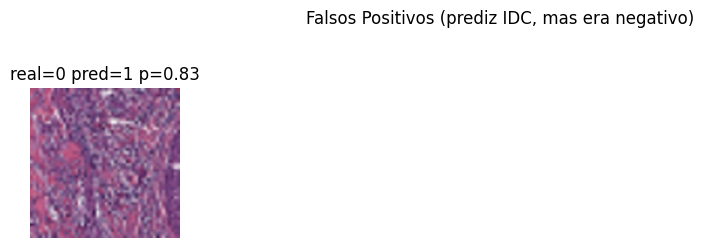

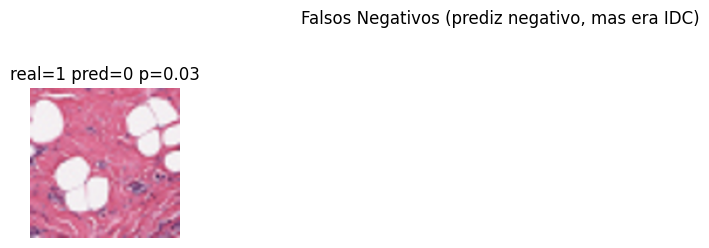

In [16]:
# Inspecao dos erros: exemplos de FP e FN
mis_idx = np.where(pred_opt != y_true)[0]
fp_idx = [i for i in mis_idx if y_true[i] == 0 and pred_opt[i] == 1][:6]
fn_idx = [i for i in mis_idx if y_true[i] == 1 and pred_opt[i] == 0][:6]

print(f"Total erros (threshold={best_thr:.3f}): {len(mis_idx)}")
print(f"Falsos positivos: {len([i for i in mis_idx if y_true[i]==0 and pred_opt[i]==1])}")
print(f"Falsos negativos: {len([i for i in mis_idx if y_true[i]==1 and pred_opt[i]==0])}")

def plot_error_examples(indices, title):
    if len(indices) == 0:
        print(f"Sem exemplos para: {title}")
        return
    plt.figure(figsize=(12, 4))
    for j, i in enumerate(indices):
        img = Image.open(X_test[i]).convert("RGB").resize(IMG_SIZE)
        ax = plt.subplot(2, 3, j + 1)
        plt.imshow(img)
        plt.title(f"real={y_true[i]} pred={pred_opt[i]} p={y_prob[i]:.2f}")
        plt.axis("off")
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

plot_error_examples(fp_idx, "Falsos Positivos (prediz IDC, mas era negativo)")
plot_error_examples(fn_idx, "Falsos Negativos (prediz negativo, mas era IDC)")

## 8) Conclusão técnica do experimento

### Síntese do que foi feito
- Definimos o target clínico (`IDC` ausente/presente).
- Construímos pipeline de visão computacional com PyTorch (EDA, split estratificado, CNN, avaliação e análise de erro).
- Incluímos avaliação por métricas complementares e ajuste de threshold orientado por validação.

### Principais aprendizados
- A análise visual e quantitativa das imagens ajudou a justificar pré-processamento e arquitetura.
- O modelo é capaz de capturar padrões úteis, mas mantém erros relevantes (FP/FN) que precisam de controle.
- Ajuste de threshold muda o equilíbrio entre `precision` e `recall`, ponto-chave para contexto médico.

### Recomendação de uso
Este modelo é apropriado como **suporte à triagem** e priorização de revisão, não como decisão autônoma. A decisão diagnóstica final deve permanecer com o(a) médico(a), integrada ao contexto clínico e outros exames.

A seguir, listamos **limitações e delimitações** explícitas para o relatório e a banca.

### Limitações e delimitações (obrigatório em trabalho acadêmico)

- **Generalização:** o desempenho vale para **este conjunto** e condições de aquisição semelhantes; outros laboratórios, corantes ou scanners podem degradar métricas (**domain shift**).
- **Unidade de amostragem:** o split é por **arquivo de imagem**. Se vários recortes vierem da **mesma lâmina/paciente** e estiverem em treino e teste, a métrica pode ser **otimista** (vazamento); em dados reais, o ideal é split por ID de paciente/lâmina quando disponível.
- **Rótulos e qualidade:** não auditamos rótulos nem artefatos de imagem neste notebook; erros de anotação propagam para o modelo.
- **Complexidade do modelo:** CNN treinada do zero é didática; em aplicações reais costuma-se comparar com **baselines** ou **backbones pré-treinados** (escopo além do mínimo exigido).
- **Uso clínico:** o sistema é **apoio à decisão**; o **diagnóstico final** permanece com o profissional de saúde e demais exames.